In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.backends.backend_pdf import PdfPages
from pybaselines import Baseline, utils
import lmfit as lm
from lmfit import Model, Parameters, Parameter, report_fit, minimize, Minimizer
from scipy.signal import find_peaks

In [2]:
def process_files(txt_folder, num_files=15):
    files = [f for f in os.listdir(txt_folder) if not f.startswith('.')]
    files = files[:num_files]  # Vybereme pouze prvních 100 souborů
    df_tim, df_amp = [], []

    for f in files:
        print(f)
        txt_file = os.path.join(txt_folder, f)
        df_tim.append(pd.read_csv(txt_file, header=5, sep=",", usecols=[0]))
        df_amp.append(pd.read_csv(txt_file, header=5, sep=",", usecols=[1]))

    df_all_tim = pd.concat(df_tim, ignore_index=True, axis=1)
    df_all_amp = pd.concat(df_amp, ignore_index=True, axis=1)

    df_all_tim.to_csv('time.csv', sep=',')
    df_all_amp.to_csv('ampl.csv', sep=',')

    df_mean_tim = df_all_tim.mean(axis=1)
    df_mean_tim.to_csv('time_aver.txt', sep=',')
    df_mean_amp = df_all_amp.mean(axis=1)
    df_mean_amp.to_csv('ampl_aver.txt', sep=',')

    with open('averaged.txt', 'w') as f:
        pd.concat([df_mean_tim, df_mean_amp], axis=1).to_csv(f, sep=',')

    print('!Averaging finished!')

# Použití
txt_folder = '2fexp25'
process_files(txt_folder, num_files=15)

C2_2025-03-06_PS_K2_25proCO2_00000.txt
C2_2025-03-06_PS_K2_25proCO2_00001.txt
C2_2025-03-06_PS_K2_25proCO2_00002.txt
C2_2025-03-06_PS_K2_25proCO2_00003.txt
C2_2025-03-06_PS_K2_25proCO2_00004.txt
C2_2025-03-06_PS_K2_25proCO2_00005.txt
C2_2025-03-06_PS_K2_25proCO2_00006.txt
C2_2025-03-06_PS_K2_25proCO2_00007.txt
C2_2025-03-06_PS_K2_25proCO2_00008.txt
C2_2025-03-06_PS_K2_25proCO2_00009.txt
C2_2025-03-06_PS_K2_25proCO2_00010.txt
C2_2025-03-06_PS_K2_25proCO2_00011.txt
C2_2025-03-06_PS_K2_25proCO2_00012.txt
C2_2025-03-06_PS_K2_25proCO2_00013.txt
C2_2025-03-06_PS_K2_25proCO2_00014.txt
!Averaging finished!


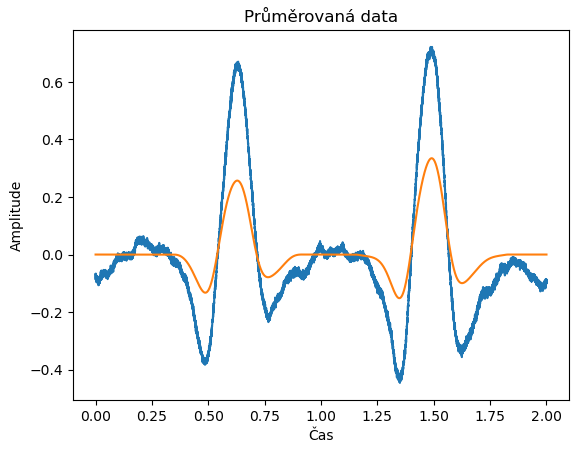

In [3]:
# ------------------------------------------------------------
# 2a) Načtení experimentálních dat (neznámá koncentrace)
# ------------------------------------------------------------
# Načtení průměrovaných dat ze souborů
df_mean_tim = pd.read_csv('time_aver.txt', sep=',', header= None, skiprows=1)
df_mean_amp = pd.read_csv('ampl_aver.txt', sep=',', header= None,  skiprows=1)
# Převod na numpy array
x_exp = df_mean_tim[1].to_numpy()
y_exp = df_mean_amp[1].to_numpy()

# Posun hodnot na x-ové ose o 2 sekundy
x_exp = x_exp + 2

# ------------------------------------------------------------
# 2b) Načtení referenční masky (10% CO₂)
# ------------------------------------------------------------
df_mask = pd.read_csv("gzeroed.csv")
x_mask = df_mask["x"].values
y_mask = df_mask["y_zeroed"].values

# interpolace masky na osu experimentu
y_mask_interp = np.interp(x_exp, x_mask, y_mask)

# Vykreslení grafu
plt.plot(x_exp, y_exp, x_mask, y_mask)
plt.xlabel('Čas')
plt.ylabel('Amplitude')
plt.title('Průměrovaná data')
plt.show()


LMFit výsledné parametry:
P = 2.418664   (škálovací faktor ~ koncentrace CO₂)
a = -3.949304e-02
b = 3.120517e-03
Korektovaná časová řada uložena do gzeroed_fitted.csv


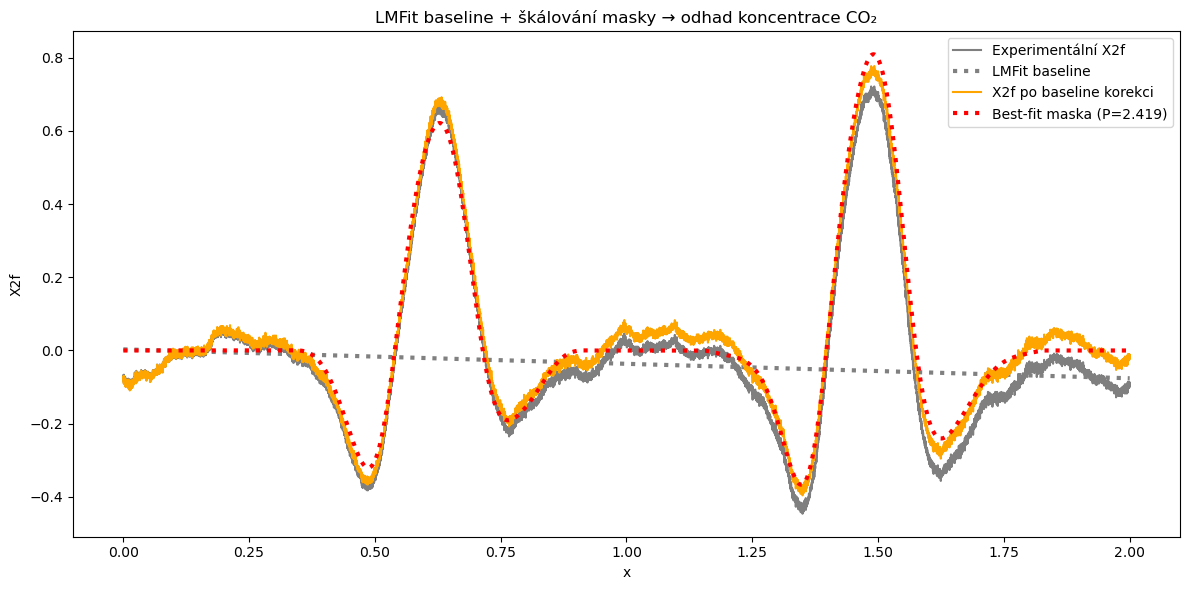

Odhad koncentrace CO₂ ≈ 24.187 %


In [4]:
# ------------------------------------------------------------
# 3) LMFit model: y_exp ≈ P * mask + (a*x + b)
# ------------------------------------------------------------
def model_func(x, P, a, b):
    return P * y_mask_interp + a*x + b

model = Model(model_func)
params = model.make_params(P=1.0, a=0.0, b=0.0)

result = model.fit(y_exp, params, x=x_exp)

P_fit = result.params["P"].value
a_fit = result.params["a"].value
b_fit = result.params["b"].value

print("LMFit výsledné parametry:")
print(f"P = {P_fit:.6f}   (škálovací faktor ~ koncentrace CO₂)")
print(f"a = {a_fit:.6e}")
print(f"b = {b_fit:.6e}")

# ------------------------------------------------------------
# 4) Korekce baseline a rekonstrukce best-fit signálu
# ------------------------------------------------------------
baseline = a_fit * x_exp + b_fit
y_corrected = y_exp - baseline
y_bestfit = P_fit * y_mask_interp

# ------------------------------------------------------------
# 5) Uložení korektované časové řady
# ------------------------------------------------------------
df_zeroed = pd.DataFrame({
    "x": x_exp,
    "y_zeroed": y_corrected,
    "y_bestfit": y_bestfit
})
df_zeroed.to_csv("gzeroed_fitted.csv", index=False)
print("Korektovaná časová řada uložena do gzeroed_fitted.csv")

# ------------------------------------------------------------
# 6) Vizualizace
# ------------------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(x_exp, y_exp, label="Experimentální X2f", linewidth=1.5, alpha=0.5, color="k")
plt.plot(x_exp, baseline, label="LMFit baseline", linestyle=":",  linewidth=3,  color="grey")
plt.plot(x_exp, y_corrected, label="X2f po baseline korekci", linewidth=1.5, color="orange")
plt.plot(x_exp, y_bestfit, label=f"Best-fit maska (P={P_fit:.3f})", linestyle=":",  linewidth=3, color="red")

plt.legend()
plt.title("LMFit baseline + škálování masky → odhad koncentrace CO₂")
plt.xlabel("x")
plt.ylabel("X2f")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7) Odhad koncentrace CO₂
# ------------------------------------------------------------
CO2_ref = 10.0  # %
CO2_est = P_fit * CO2_ref
print(f"Odhad koncentrace CO₂ ≈ {CO2_est:.3f} %")
